# Exp 9: Custom CNN + Bi-GRU + FCNN (Encoder-Decoder)

**Goal:** Fully custom encoder-decoder architecture. No pretrained models whatsoever.

**Architecture:**
```
Image [3,224,224] → CNN Encoder (4 conv blocks) → GAP → img_feat [256]
Text  [seq_len]   → Embedding → Bi-GRU Decoder  → txt_feat [256]
                 → Concat [512] → FCNN → 1
```

**CNN Encoder:** Conv→BN→ReLU→MaxPool ×4, trained from scratch.

**Bi-GRU Decoder:** Word embeddings (trained from scratch) → Bi-GRU → concat(fwd, bwd) final hidden.

In [ ]:
!pip install -q jsonlines

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from collections import Counter
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import json, copy, os
import jsonlines
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub, shutil, os, sys
from pathlib import Path

# Download dataset to Colab SSD (much faster than Drive FUSE)
path = kagglehub.dataset_download("parthplc/facebook-hateful-meme-dataset")
print("Downloaded to:", path)

for root, dirs, files in os.walk(path):
    for f in files[:5]:
        print(os.path.join(root, f))

100%|██████████| 3.35G/3.35G [00:46<00:00, 78.2MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/train.jsonl
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/dev.jsonl
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/README.md
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/LICENSE.txt
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/test.jsonl
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img/40723.png
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img/83476.png
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img/48039.png
/root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img/56281.png
/root/.ca

In [ ]:
ROOT    = Path(path) / 'data'
IMG_DIR = ROOT / 'img'

RESULTS_DIR = 'content/results'
MODELS_DIR  = 'content/models'
OUTPUTS_DIR = 'content/outputs'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f'ROOT   : {ROOT}')
print(f'IMG_DIR: {IMG_DIR}')

ROOT   : /root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data
IMG_DIR: /root/.cache/kagglehub/datasets/parthplc/facebook-hateful-meme-dataset/versions/1/data/img


In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Load Data

In [ ]:
def load_jsonl(path):
    data = []
    with jsonlines.open(path) as reader:
        for item in reader:
            data.append(item)
    return data

train_data = load_jsonl(ROOT / 'train.jsonl')
dev_data   = load_jsonl(ROOT / 'dev.jsonl')
print(f'Train: {len(train_data)} | Dev: {len(dev_data)}')
print(f'Sample: {train_data[0]}')

Train: 8500 | Dev: 500
Sample: {'id': 42953, 'img': 'img/42953.png', 'label': 0, 'text': 'its their character not their color that matters'}


## 2. Build Vocabulary (from scratch)

In [ ]:
# Simple whitespace tokenizer — no pretrained tokenizer
def simple_tokenize(text):
    return text.lower().split()

# Build vocab from train set only
counter = Counter()
for item in train_data:
    counter.update(simple_tokenize(item['text']))

MIN_FREQ  = 2
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
vocab     = [PAD_TOKEN, UNK_TOKEN] + [w for w, c in counter.items() if c >= MIN_FREQ]
word2idx  = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
PAD_IDX    = word2idx[PAD_TOKEN]
UNK_IDX    = word2idx[UNK_TOKEN]

print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'PAD_IDX: {PAD_IDX} | UNK_IDX: {UNK_IDX}')

Vocabulary size: 5829
PAD_IDX: 0 | UNK_IDX: 1


## 3. Dataset & DataLoaders

In [ ]:
MAX_LEN  = 32   # hateful memes text is short — median 10 words
IMG_SIZE = 224

img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def encode_text(text, max_len=MAX_LEN):
    tokens = simple_tokenize(text)[:max_len]
    ids    = [word2idx.get(t, UNK_IDX) for t in tokens]
    ids   += [PAD_IDX] * (max_len - len(ids))
    return ids

class HatefulMemesDataset(Dataset):
    def __init__(self, data, img_dir, transform, max_len=MAX_LEN):
        self.data      = data
        self.img_dir   = Path(img_dir)
        self.transform = transform
        self.max_len   = max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item    = self.data[idx]
        image   = Image.open(self.img_dir / item['img'].split('/')[-1]).convert('RGB')
        img_t   = self.transform(image)
        text_t  = torch.tensor(encode_text(item['text'], self.max_len), dtype=torch.long)
        lengths = (text_t != PAD_IDX).sum().long()
        label   = torch.tensor(item['label'], dtype=torch.float32)
        return img_t, text_t, lengths, label

BATCH_SIZE   = 64
train_ds     = HatefulMemesDataset(train_data, IMG_DIR, img_transform)
dev_ds       = HatefulMemesDataset(dev_data,   IMG_DIR, img_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

n_pos      = sum(d['label'] for d in train_data)
n_neg      = len(train_data) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f'Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)}')
print(f'pos_weight: {pos_weight.item():.3f}')

Train batches: 133 | Dev batches: 8
pos_weight: 1.787


## 4. Model — CNN Encoder + Bi-GRU Decoder + FCNN

### CNN Encoder
Four conv blocks: `Conv2d → BatchNorm2d → ReLU → MaxPool2d`
- Block 1: 3→32, Block 2: 32→64, Block 3: 64→128, Block 4: 128→256
- Global Average Pooling → [256] → Linear(256)

### Bi-GRU Decoder
- `nn.Embedding(vocab_size, 128)` — learned from scratch
- `nn.GRU(128, 128, bidirectional=True)` — pack/unpack for variable lengths
- Concat final fwd + bwd hidden → [256] → Linear(256)

### FCNN Classifier
- Concat(img_feat, txt_feat) [512] → Linear(256) → ReLU → Linear(128) → ReLU → Linear(1)

In [ ]:
class CNNEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )
        self.features = nn.Sequential(
            conv_block(3,   32),   # 224 -> 112
            conv_block(32,  64),   # 112 -> 56
            conv_block(64, 128),   # 56  -> 28
            conv_block(128, 256),  # 28  -> 14
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(256, out_dim)

    def forward(self, x):
        x = self.features(x)          # [B, 256, 14, 14]
        x = self.gap(x).flatten(1)    # [B, 256]
        return self.proj(x)            # [B, out_dim]


class BiGRUDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, out_dim=256,
                 pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            bidirectional=True, batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.proj    = nn.Linear(hidden_dim * 2, out_dim)

    def forward(self, token_ids, lengths):
        emb = self.dropout(self.embedding(token_ids))  # [B, seq, embed_dim]
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)  # hidden: [2, B, hidden_dim]
        txt = torch.cat([hidden[0], hidden[1]], dim=-1)  # [B, 2*hidden_dim]
        return self.proj(self.dropout(txt))               # [B, out_dim]


class CNNBiGRUFCNN(nn.Module):
    def __init__(self, vocab_size, pad_idx,
                 cnn_dim=256, embed_dim=128, gru_hidden=128, gru_dim=256,
                 fcnn_hidden=256, dropout=0.4):
        super().__init__()
        self.cnn_encoder = CNNEncoder(out_dim=cnn_dim)
        self.gru_decoder = BiGRUDecoder(
            vocab_size, embed_dim=embed_dim, hidden_dim=gru_hidden,
            out_dim=gru_dim, pad_idx=pad_idx, dropout=dropout
        )
        fused_dim = cnn_dim + gru_dim
        self.fcnn = nn.Sequential(
            nn.Linear(fused_dim, fcnn_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fcnn_hidden, fcnn_hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fcnn_hidden // 2, 1)
        )

    def forward(self, images, token_ids, lengths):
        img_feat = self.cnn_encoder(images)
        txt_feat = self.gru_decoder(token_ids, lengths)
        fused    = torch.cat([img_feat, txt_feat], dim=-1)
        return self.fcnn(fused).squeeze(-1)


model = CNNBiGRUFCNN(vocab_size=VOCAB_SIZE, pad_idx=PAD_IDX).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')
print(model)

Trainable params: 1,629,569
CNNBiGRUFCNN(
  (cnn_encoder): CNNEncoder(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (1): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kern

## 5. Optimizer & Scheduler

In [ ]:
EPOCHS    = 20
PATIENCE  = 5
LR        = 3e-4

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Epochs: {EPOCHS} | LR: {LR} | Patience: {PATIENCE}')

Epochs: 20 | LR: 0.0003 | Patience: 5


## 6. Training Loop

In [ ]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []

    for images, token_ids, lengths, y in loader:
        images, token_ids = images.to(DEVICE), token_ids.to(DEVICE)
        lengths, y        = lengths.to(DEVICE), y.to(DEVICE)

        with autocast():
            logits = model(images, token_ids, lengths)
            loss   = criterion(logits, y)

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * len(y)
        all_probs.extend(torch.sigmoid(logits).detach().float().cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


history = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
best_dev_auc, best_state, patience_ctr = 0.0, None, 0

print('Training: Custom CNN + Bi-GRU + FCNN (all from scratch)')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer)
    dv_loss, dv_auc, dv_acc, _, _ = run_epoch(dev_loader,   model, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['dev_loss'].append(dv_loss)
    history['train_auc'].append(tr_auc);   history['dev_auc'].append(dv_auc)

    if dv_auc > best_dev_auc:
        best_dev_auc = dv_auc; best_state = copy.deepcopy(model.state_dict())
        patience_ctr = 0; flag = '  <- best'
    else:
        patience_ctr += 1; flag = f'  (patience {patience_ctr}/{PATIENCE})'

    print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} Acc {tr_acc:.4f} | '
          f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch}'); break

model.load_state_dict(best_state)
print(f'\nBest Dev AUC: {best_dev_auc:.4f}')

Training: Custom CNN + Bi-GRU + FCNN (all from scratch)
Ep 01 | Tr Loss 0.8834 AUC 0.5538 Acc 0.5204 | Dev Loss 0.9863 AUC 0.5152 Acc 0.5000  <- best
Ep 02 | Tr Loss 0.8741 AUC 0.5916 Acc 0.5673 | Dev Loss 0.9970 AUC 0.5040 Acc 0.4880  (patience 1/5)
Ep 03 | Tr Loss 0.8612 AUC 0.6181 Acc 0.5756 | Dev Loss 0.9544 AUC 0.5238 Acc 0.5140  <- best
Ep 04 | Tr Loss 0.8403 AUC 0.6566 Acc 0.6064 | Dev Loss 1.2004 AUC 0.5761 Acc 0.5180  <- best
Ep 05 | Tr Loss 0.8114 AUC 0.6944 Acc 0.6444 | Dev Loss 1.1124 AUC 0.5564 Acc 0.5420  (patience 1/5)
Ep 06 | Tr Loss 0.7979 AUC 0.7124 Acc 0.6505 | Dev Loss 0.9843 AUC 0.5189 Acc 0.4860  (patience 2/5)
Ep 07 | Tr Loss 0.7811 AUC 0.7278 Acc 0.6616 | Dev Loss 1.0874 AUC 0.5768 Acc 0.5640  <- best
Ep 08 | Tr Loss 0.7563 AUC 0.7533 Acc 0.6835 | Dev Loss 1.0989 AUC 0.6045 Acc 0.5620  <- best
Ep 09 | Tr Loss 0.7344 AUC 0.7704 Acc 0.6987 | Dev Loss 1.2446 AUC 0.6250 Acc 0.5740  <- best
Ep 10 | Tr Loss 0.7125 AUC 0.7869 Acc 0.7119 | Dev Loss 1.1170 AUC 0.6110 Acc

## 7. Training Curves

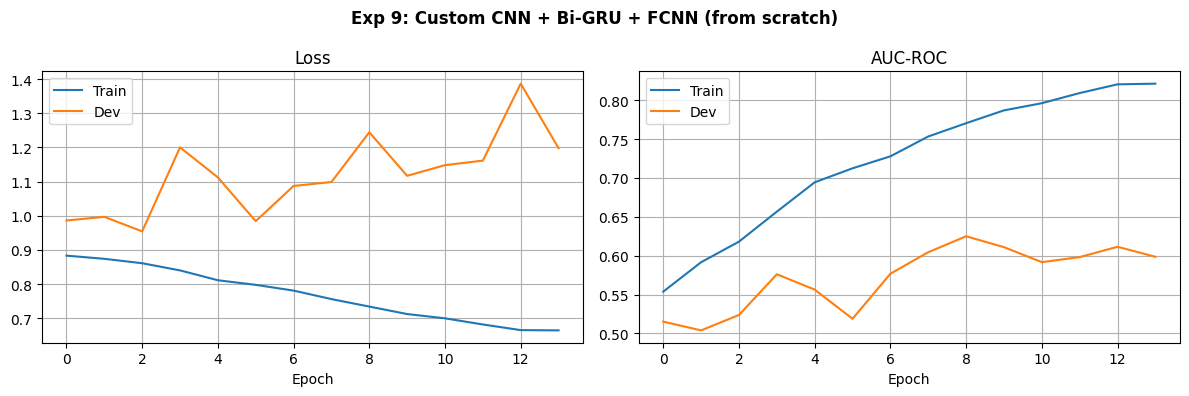

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['dev_loss'], label='Dev')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history['train_auc'], label='Train'); axes[1].plot(history['dev_auc'], label='Dev')
axes[1].set_title('AUC-ROC'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Exp 9: Custom CNN + Bi-GRU + FCNN (from scratch)', fontweight='bold')
plt.tight_layout()
plt.savefig('content/outputs/09_training_curves.png', dpi=150)
plt.show()

## 8. Evaluate & Save

In [ ]:
_, dev_auc, dev_acc, dev_probs, dev_true = run_epoch(dev_loader, model, criterion)
dev_preds = (dev_probs >= 0.5).astype(int)
print('=' * 55)
print('EXP 9 — CNN + Bi-GRU + FCNN | Dev Set')
print('=' * 55)
print(f'AUC-ROC  : {dev_auc:.4f}')
print(f'Accuracy : {dev_acc:.4f}')
print()
print(classification_report(dev_true, dev_preds, target_names=['Not Hateful', 'Hateful']))

torch.save(best_state, 'content/models/09_cnn_bigru_fcnn.pt')

# Save vocab for exp 10 and 11
with open('content/results/vocab.json', 'w') as f:
    json.dump({'word2idx': word2idx, 'vocab_size': VOCAB_SIZE,
               'pad_idx': PAD_IDX, 'unk_idx': UNK_IDX}, f)

exp9_out = {
    'experiment': '09_CNN_BiGRU_FCNN',
    'pipeline': 'Custom CNN (4 conv blocks) + Bi-GRU (scratch embeds) -> concat -> FCNN',
    'pretrained': False,
    'results': {'dev_auc_roc': round(float(dev_auc), 4), 'dev_accuracy': round(float(dev_acc), 4)},
    'architecture': {
        'cnn': '4 conv blocks (3->32->64->128->256) + GAP + Linear(256)',
        'bigru': f'Embedding({VOCAB_SIZE}, 128) + BiGRU(128, 128) + Linear(256)',
        'fcnn': 'Linear(512, 256) -> ReLU -> Linear(256, 128) -> ReLU -> Linear(1)'
    }
}
with open('content/results/exp9.json', 'w') as f:
    json.dump(exp9_out, f, indent=2)

print('Model   -> content/models/09_cnn_bigru_fcnn.pt')
print('Results -> content/results/exp9.json')
print('Vocab   -> content/results/vocab.json  (needed by exp 10 & 11)')
print(json.dumps(exp9_out, indent=2))

EXP 9 — CNN + Bi-GRU + FCNN | Dev Set
AUC-ROC  : 0.6250
Accuracy : 0.5740

              precision    recall  f1-score   support

 Not Hateful       0.55      0.87      0.67       250
     Hateful       0.68      0.28      0.40       250

    accuracy                           0.57       500
   macro avg       0.61      0.57      0.53       500
weighted avg       0.61      0.57      0.53       500

Model   -> content/models/09_cnn_bigru_fcnn.pt
Results -> content/results/exp9.json
Vocab   -> content/results/vocab.json  (needed by exp 10 & 11)
{
  "experiment": "09_CNN_BiGRU_FCNN",
  "pipeline": "Custom CNN (4 conv blocks) + Bi-GRU (scratch embeds) -> concat -> FCNN",
  "pretrained": false,
  "results": {
    "dev_auc_roc": 0.625,
    "dev_accuracy": 0.574
  },
  "architecture": {
    "cnn": "4 conv blocks (3->32->64->128->256) + GAP + Linear(256)",
    "bigru": "Embedding(5829, 128) + BiGRU(128, 128) + Linear(256)",
    "fcnn": "Linear(512, 256) -> ReLU -> Linear(256, 128) -> ReLU -> L